# 03 — Exploratory Data Analysis

---

## Objective

The objective of this notebook is to understand the statistical properties of the prediction-market dataset before constructing Bayesian fair-value models.

This exploratory analysis focuses on:

- Market durations
- Trading activity
- Liquidity characteristics
- Probability distributions
- Probability trajectories
- Outcome frequencies
- Market-level heterogeneity

The goal is to identify structural patterns that may later explain market mispricing and calibration errors.

---

## Research Questions

- How are implied probabilities distributed?
- Are resolved outcomes balanced?
- How much liquidity exists across markets?
- How volatile are market probabilities?
- Do probabilities converge toward the correct outcome?
- Are some markets systematically more uncertain than others?

---

## Expected Outputs

- Descriptive statistics
- Distribution plots
- Liquidity analysis
- Probability trajectory examples
- Outcome imbalance analysis
- Preliminary calibration intuition

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)

# historical probabilities
df_prices = pd.read_csv("../data/raw/prices_raw.csv")
# market-level dataset
df_market = pd.read_csv("../data/processed/market_dataset.csv")
print(df_prices.shape)
print(df_market.shape)

(100642, 5)
(43, 30)


In [5]:
# Data orverview 
df_prices["timestamp"] = pd.to_datetime(df_prices["timestamp"],utc=True)
print("markets:", df_market["market_id"].nunique())
print("bbservations:", len(df_prices))
print("Start:",df_prices["timestamp"].min())
print("End:",df_prices["timestamp"].max())
print("\Outcome distribution:")
print(df_market["outcome"].value_counts())

markets: 43
bbservations: 100642
Start: 2023-02-07 01:00:32+00:00
End: 2024-12-30 23:00:04+00:00
\Outcome distribution:
outcome
0    29
1    14
Name: count, dtype: int64


<>:7: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\O'
C:\Users\avazq\AppData\Local\Temp\ipykernel_15012\644552021.py:7: SyntaxWarning: invalid escape sequence '\O'
  print("\Outcome distribution:")


- markets: 43 and observations: 100,642
- temporal interval aprox  : 23 months 
- Outcome Imbalance :  
   1. Outcome = 0 : 29 markets | Outcome = 1 : 14 markets
   2. NO : 67.4%  | YES : 32.6%
   

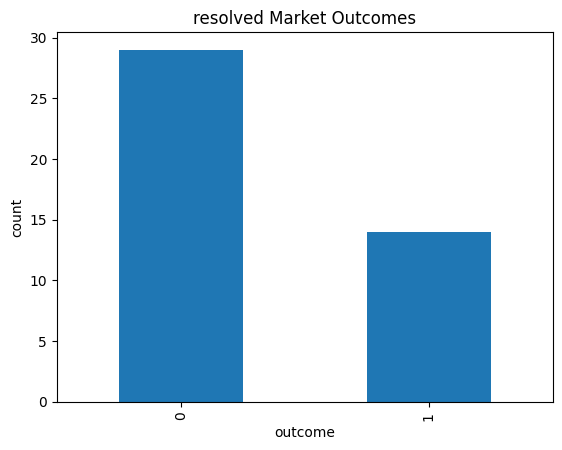

In [6]:
outcome_counts = (df_market["outcome"].value_counts().sort_index())
outcome_counts.plot(kind="bar")

plt.title("resolved Market Outcomes")
plt.xlabel("outcome")
plt.ylabel("count")

plt.show()

In [8]:
df_market["final_probability"].describe()

count    43.000000
mean      0.318523
std       0.396041
min       0.000500
25%       0.005250
50%       0.050000
75%       0.557500
max       0.999500
Name: final_probability, dtype: float64

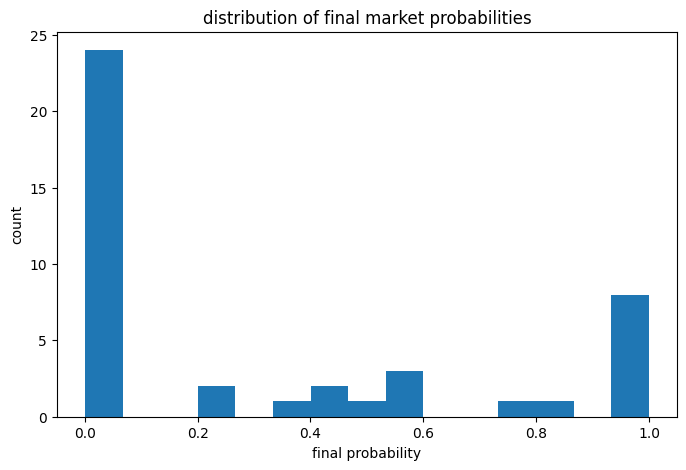

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df_market["final_probability"],bins=15)
plt.title("distribution of final market probabilities")
plt.xlabel("final probability")
plt.ylabel("count")
plt.show()

- Predictive Markets don´t end up  uniformly  distributed. If Polymarket were tracked until expiration,  we would see more high and low  frequency  repeating patters.
- Median = 0.05: This means that 50% of the prediction markets end up with a final probability less than or equal to 5%.
- Skewness (Right Tail):  Since the mean (0.318) is greater than the median (0.05), the distribution is positively skewed, commonly indicating the existence of a right - tail.
- Coherence Outcome: A large number of final probabilities are close to 0.

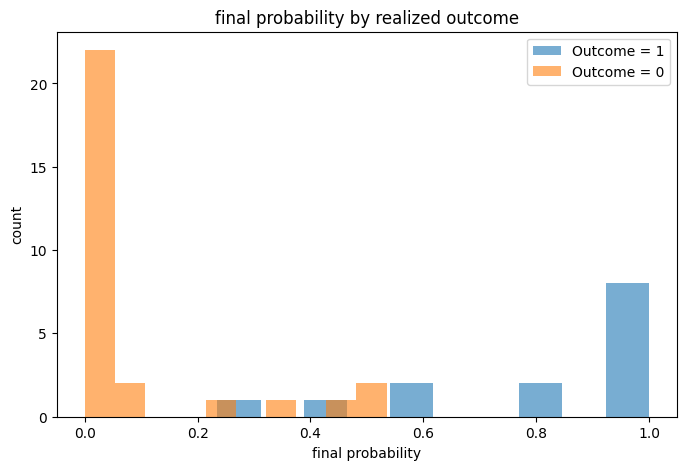

In [10]:
#¿Los mercados que terminaron ocurriendo
#tenían probabilidades altas?
#¿Los mercados que NO ocurrieron
#tenían probabilidades bajas?



plt.figure(figsize=(8,5))
plt.hist(df_market.loc[df_market["outcome"] == 1,"final_probability"],bins=10,alpha=0.6,label="Outcome = 1")
plt.hist(df_market.loc[df_market["outcome"] == 0,"final_probability"],bins=10,alpha=0.6,label="Outcome = 0")
plt.legend()
plt.title("final probability by realized outcome")
plt.xlabel("final probability")
plt.ylabel("count")
plt.show()

Key insight : zone in [0.3,0.4, 0.5, 0.6]  :  This means there are markets where participants were unsure. That is exactly where markets become interesting, because that is where mispricings potentially arise.

---

Preliminary exploratory analysis suggests that market-implied probabilities contain substantial predictive information regarding realized outcomes. However, outcome classes remain partially overlapping across intermediate probability levels, indicating the potential existence of calibration errors and systematic mispricing opportunities.

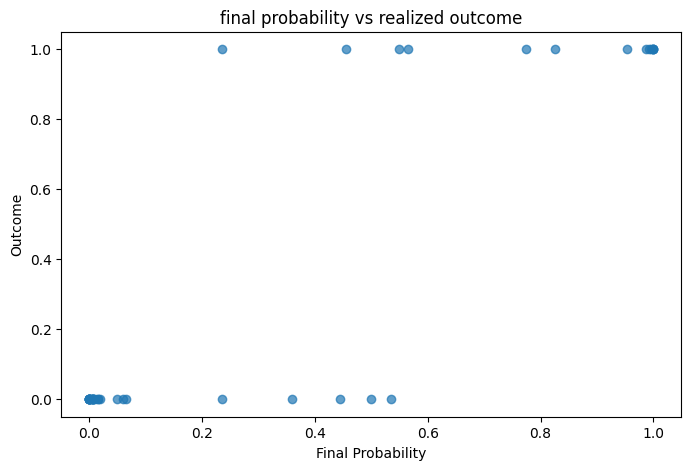

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(df_market["final_probability"],df_market["outcome"],alpha=0.7)
plt.xlabel("Final Probability")
plt.ylabel("Outcome")
plt.title("final probability vs realized outcome")
plt.show()

Markets where the consensus ended up being wrong

If you consistently find scenarios where the market price is at 25% but the realized outcome is 100%, it means the market underestimated the event, presenting a buying opportunity.Conversely, if the market price is at 70% and the realized outcome is 0%, the market overestimated the event, meaning there was value in selling.